In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv('leads.csv')

In [42]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   LeadCreated                  3021 non-null   object 
 1   FirstName                    3021 non-null   object 
 2   Email                        3021 non-null   object 
 3   VendorLeadID                 3021 non-null   object 
 4   CallStatus                   881 non-null    object 
 5   WidgetName                   3021 non-null   object 
 6   PublisherZoneName            3021 non-null   object 
 7   PublisherCampaignName        3021 non-null   object 
 8   AddressScore                 1171 non-null   float64
 9   PhoneScore                   1393 non-null   float64
 10  AdvertiserCampaignName       3021 non-null   object 
 11  State                        3021 non-null   object 
 12  DebtLevel                    3021 non-null   object 
 13  IP Address        

,AddressScore,PhoneScore,IP Address
count,1171.000000,1393.000000,0.0
mean,4.286080,3.903087,NaN
std,1.345192,1.101826,NaN
min,1.000000,1.000000,NaN
25%,4.000000,3.000000,NaN
50%,5.000000,4.000000,NaN
75%,5.000000,5.000000,NaN
max,5.000000,5.000000,NaN


In [43]:
df.head(5)

,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,...,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters
0,7/1/2009,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,...,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...
1,4/13/2009,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
2,4/21/2009,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
3,8/3/2009,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-302252-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.0,3.0,...,Google,norwich.kijiji.com,DebtReductionInc,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...
4,4/13/2009,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,...,Google,NaN,DebtReductionInc,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...


In [44]:
good_statuses = ['Closed', 'EP Sent', 'EP Received', 'EP Confirmed']
bad_statuses = ['Unable to contact - Bad Contact Information', 
                'Contacted - Invalid Profile', 
                "Contacted - Doesn't Qualify"]

In [45]:
def classify(status):
    if status in good_statuses:
        return 'Good'
    elif status in bad_statuses:
        return 'Bad'
    else:
        return 'Unknown'

df['Quality'] = df['CallStatus'].apply(classify)

In [46]:
print(df['Quality'].value_counts())

Quality
Unknown    2140
Bad         488
Good        393
Name: count, dtype: int64


In [47]:
df['LeadCreated'] = pd.to_datetime(df['LeadCreated'])

In [48]:
df['Month'] = df['LeadCreated'].dt.strftime('%b')

In [49]:
month_order = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']

In [50]:
print(df['Month'].value_counts().reindex(month_order))

Month
Apr    518
May    580
Jun    609
Jul    532
Aug    438
Sep    344
Name: count, dtype: int64


In [86]:
total_by_month = df.groupby('Month')['VendorLeadID'].count()
closed_by_month = df[df['CallStatus'] == 'Closed'].groupby('Month')['VendorLeadID'].count()

monthly = pd.DataFrame({
    'Total Leads': total_by_month,
    'Closed Leads': closed_by_month
}).reindex(month_order)

monthly['Closed Rate %'] = (monthly['Closed Leads'] / monthly['Total Leads'] * 100).round(0)
print(monthly)

       Total Leads  Closed Leads  Closed Rate %
Month                                          
Apr            518            56           11.0
May            580            37            6.0
Jun            609            63           10.0
Jul            532            33            6.0
Aug            438            41            9.0
Sep            344            15            4.0


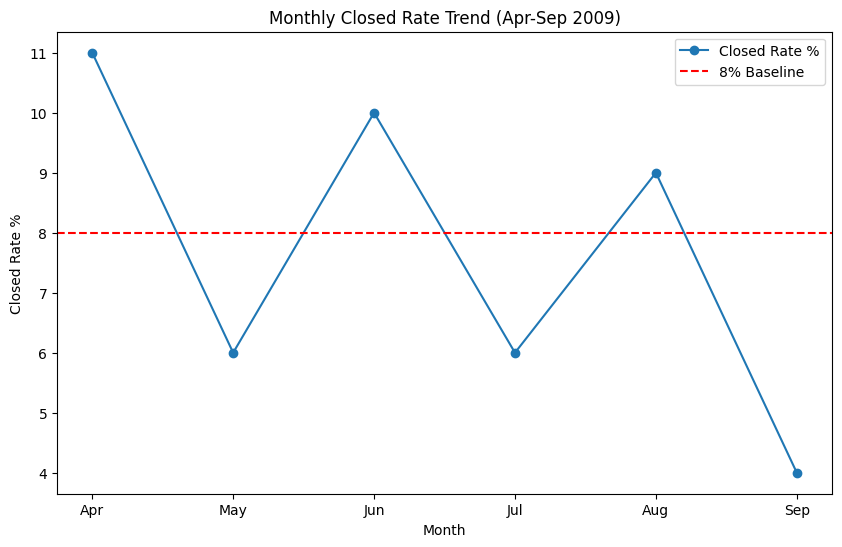

In [54]:
monthly['Closed Rate %'].plot(kind='line', 
                               figsize=(10, 6), 
                               marker='o',
                               title='Monthly Closed Rate Trend (Apr-Sep 2009)')

# Add baseline
plt.axhline(y=8, color='red', linestyle='--', label='8% Baseline')

plt.ylabel('Closed Rate %')
plt.legend()
plt.show()

# Finding
Lead quality shows no statistically significant upward or downward trend 
over the April–September 2009 period. The trend is volatile, oscillating 
between 6% and 11% with no clear direction. September's low rate of 4% 
likely reflects pipeline lag rather than genuine quality decline.

In [55]:
# This function calculates closed rate for any segment
def segment_analysis(column_name):
  
    total = df.groupby(column_name)['VendorLeadID'].count()
    closed = df[df['CallStatus'] == 'Closed'].groupby(column_name)['VendorLeadID'].count()
    
    result = pd.DataFrame({
        'Total Leads': total,
        'Closed Leads': closed
    })
    result['Closed Rate %'] = (result['Closed Leads'] / result['Total Leads'] * 100).round(1)
    
    # Sorting by closed rate highest to lowest
    result = result.sort_values('Closed Rate %', ascending=False)
    
    return result

print("Function created successfully!")

Function created successfully!


# Segment 1: Ad Platform (Partner)
Analyzing which advertising platform delivers the highest quality leads.  
*Hypothesis*: Different platforms attract different user intent levels.

In [89]:
# fix case sensitivity as it has google and Google
df['Partner'] = df['Partner'].str.strip().str.title()

print(df['Partner'].value_counts())

Partner
Google           1618
Yahoo             958
Call_Center       271
Adknowledge       171
Advertise.Com       3
Name: count, dtype: int64


In [90]:
print("=== CLOSED RATE BY AD PARTNER ===\n")
partner_analysis = segment_analysis('Partner')
print(partner_analysis)

=== CLOSED RATE BY AD PARTNER ===

               Total Leads  Closed Leads  Closed Rate %
Partner                                                
Advertise.Com            3             1           33.3
Adknowledge            171            21           12.3
Call_Center            271            26            9.6
Yahoo                  958            74            7.7
Google                1618           123            7.6


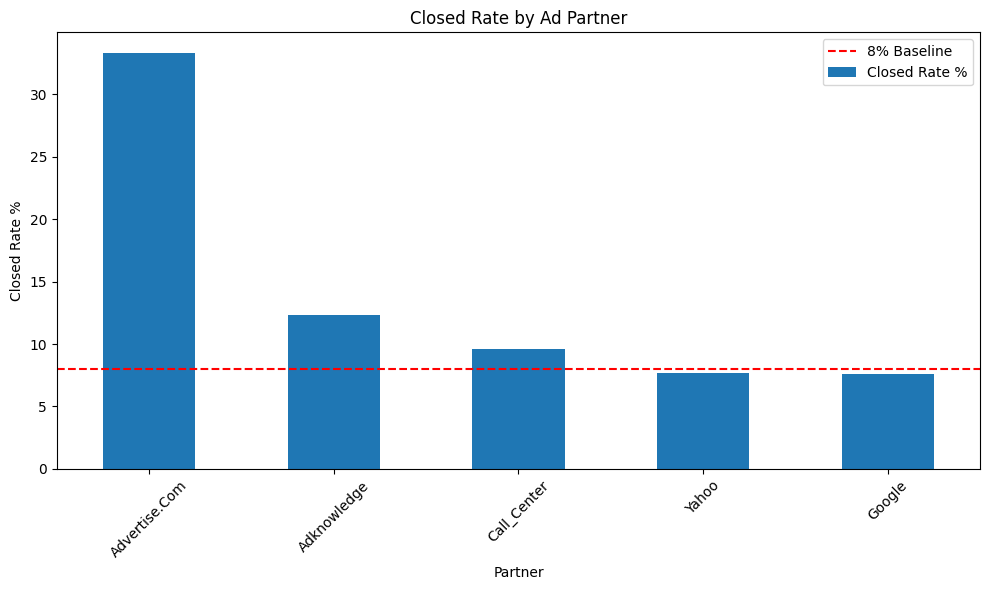

In [91]:
# Chart for Partner
partner_analysis['Closed Rate %'].plot(kind='bar',
                                        figsize=(10, 6),
                                        title='Closed Rate by Ad Partner')

plt.axhline(y=8, color='red', linestyle='--', label='8% Baseline')
plt.ylabel('Closed Rate %')
plt.xlabel('Partner')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finding
AdKnowledge delivers the highest quality leads at 12%, compared to 
Google and Yahoo at 8%. Despite this, Google receives over 50% of all 
traffic. Reallocating budget from Google to AdKnowledge would 
meaningfully lift overall closed rates.

# Segment 2: Consumer Debt Level
Analyzing whether debt amount affects likelihood of closing.  
*Hypothesis*: Mid-range debt ($10K-$90K) will perform best.

=== CLOSED RATE BY DEBT LEVEL ===

                  Total Leads  Closed Leads  Closed Rate %
DebtLevel                                                 
70001-90000               131            18           13.7
10001-15000               291            34           11.7
90000-100000               90             9           10.0
50001-70000               245            22            9.0
20001-30000               456            40            8.8
15001-20000               408            35            8.6
30001-50000               496            39            7.9
7500-15000                271            19            7.0
7500-10000                442            22            5.0
More_than_100000          191             7            3.7


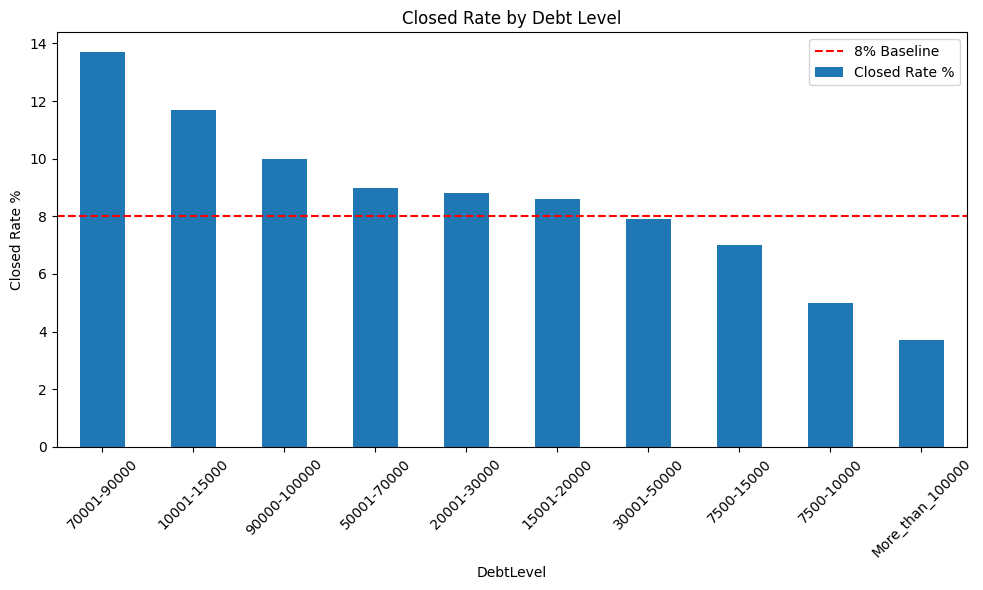

In [83]:
print("=== CLOSED RATE BY DEBT LEVEL ===\n")
debt_analysis = segment_analysis('DebtLevel')
print(debt_analysis)

debt_analysis['Closed Rate %'].plot(kind='bar',
                                     figsize=(10, 6),
                                     title='Closed Rate by Debt Level')
plt.axhline(y=8, color='red', linestyle='--', label='8% Baseline')
plt.ylabel('Closed Rate %')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Finding
The sweet spot is $10,000–$90,000 in debt, closing at 9–14%. 
Very low debt (<$10K) closes at just 5% — these consumers likely 
don't need the program badly enough. Very high debt (>$100K) 
also underperforms at 4%.

# Segment 3: Ad Creative (Widget)
Analyzing which ad design and format generates the highest quality leads.  
*Hypothesis:* Creative design and ad size will impact lead quality.

=== CLOSED RATE BY WIDGET ===

                                              Total Leads  Closed Leads  \
WidgetName                                                                
w-300250-DebtReduction1-1DC-white                       6             1   
w-300250-DebtReduction1-1DC-CreditSolutions            77            12   
w-300250-DebtReduction1-1DC-BlueMeter                  92            13   
w-300250-DebtReduction1-1DC-Head2                      89            11   
w-300250-DebtReduction1-1DC                           348            34   
w-302252-DebtReduction1-1DC                           272            23   
w-300250-DebtReduction1-2DC-CreditSolutions            75             6   
w-302252-DebtReduction1-1DC-yellowarrow-dark          135            10   
w-302252-DebtReduction1-1DC-CreditSolutions          1054            76   
w-302252-DebtReduction1-1DC-white                     430            31   
w-300250-DebtReduction1-2DC-BlueMeter                  87            

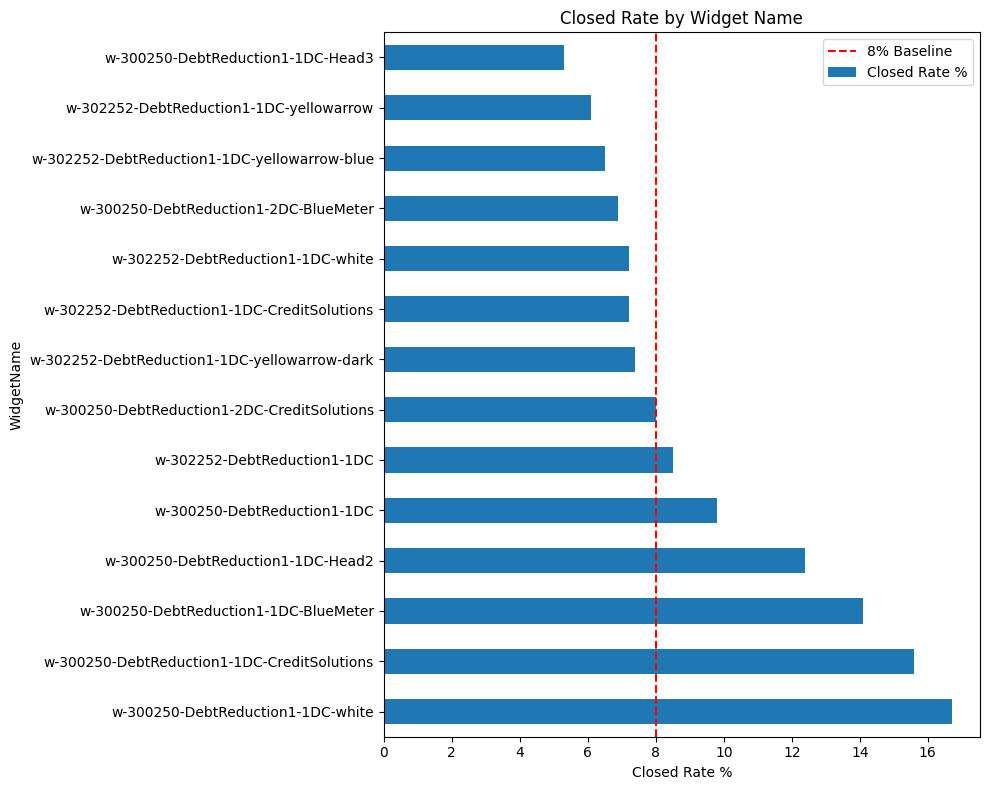

In [84]:
print("=== CLOSED RATE BY WIDGET ===\n")
widget_analysis = segment_analysis('WidgetName')
print(widget_analysis)

widget_analysis['Closed Rate %'].plot(kind='barh',
                                       figsize=(10, 8),
                                       title='Closed Rate by Widget Name')
plt.axvline(x=8, color='red', linestyle='--', label='8% Baseline')
plt.xlabel('Closed Rate %')
plt.legend()
plt.tight_layout()
plt.show()

# Finding
The 300x250 format consistently outperforms 302x252 across all variants.
CreditSolutions widget closes at 16% — double the baseline — while 
high-volume 302x252 widgets only reach 6–7%. Shifting impressions 
toward 300x250 is the single biggest quality lever available.

# Segment 4: Advertiser Campaign (Branded vs Generic)
Analyzing whether showing the advertiser's brand affects lead quality.

In [62]:
print("=== CLOSED RATE BY ADVERTISER CAMPAIGN ===\n")
campaign_analysis = segment_analysis('AdvertiserCampaignName')
print(campaign_analysis)

=== CLOSED RATE BY ADVERTISER CAMPAIGN ===

                                   Total Leads  Closed Leads  Closed Rate %
AdvertiserCampaignName                                                     
Debt Settlement1 Master                   1815           151            8.3
creditsolutions-branded-shortform         1206            94            7.8


# Finding
Virtually no difference between branded (7.8%) and generic (8.3%) 
campaigns. Branding does not meaningfully influence whether a lead closes.

# Segment 5: Publisher Campaign (Online vs Call Center)
Analyzing whether how the lead was captured affects quality.

In [63]:
print("=== CLOSED RATE BY PUBLISHER CAMPAIGN ===\n")
publisher_analysis = segment_analysis('PublisherCampaignName')
print(publisher_analysis)

=== CLOSED RATE BY PUBLISHER CAMPAIGN ===

                         Total Leads  Closed Leads  Closed Rate %
PublisherCampaignName                                            
DebtReductionCallCenter          271            26            9.6
DebtReductionInc                2750           219            8.0


# Finding
Call center leads close slightly higher (10% vs 8%), however this 
modest improvement must be weighed against the significantly higher 
operational cost of running a call center versus online form submissions.

# Question 3: Can We Achieve a 20% Quality Lift?

*Current CPL:* $30 | *Target CPL:* $33  
*Current Closed Rate:* 8.0% | *Target Closed Rate:* 9.6%

We identify three specific levers from our segment analysis that 
can push the closed rate above 9.6% and unlock the $33 CPL.

In [64]:
total_leads = len(df)
current_closed_rate = (df['CallStatus'] == 'Closed').sum() / total_leads * 100
current_cpl = 30
target_cpl = 33


In [65]:
current_revenue = total_leads * current_cpl
target_revenue = total_leads * target_cpl
revenue_uplift = target_revenue - current_revenue

In [66]:
print("=== REVENUE IMPACT ANALYSIS ===\n")
print(f"Total Leads:        {total_leads:,}")
print(f"Current Closed Rate: {current_closed_rate:.1f}%")
print(f"Target Closed Rate:  9.6%")
print(f"")
print(f"Current Revenue:    ${current_revenue:,}")
print(f"Target Revenue:     ${target_revenue:,}")
print(f"Revenue Uplift:     ${revenue_uplift:,}")

=== REVENUE IMPACT ANALYSIS ===

Total Leads:        3,021
Current Closed Rate: 8.1%
Target Closed Rate:  9.6%

Current Revenue:    $90,630
Target Revenue:     $99,693
Revenue Uplift:     $9,063


In [87]:
levers = pd.DataFrame({
    'Lever': ['Shift to AdKnowledge', 
              'Use 300x250 Widgets', 
              'Filter Debt $10K-$90K'],
    'Current Rate %': [8, 8, 8],
    'Achievable Rate %': [12, 16, 14]
})

levers.set_index('Lever', inplace=True)

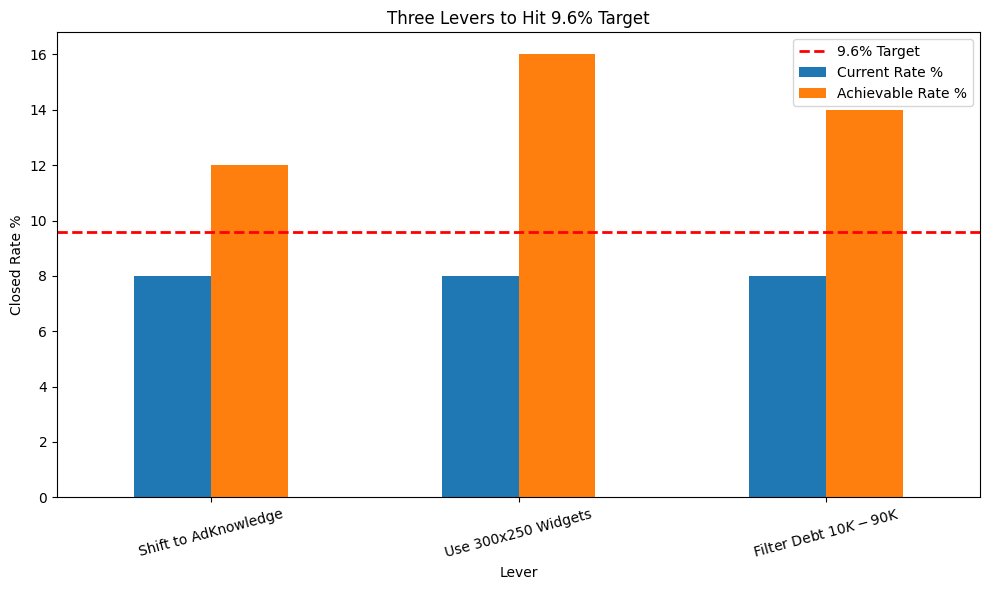

In [88]:
levers.plot(kind='bar', figsize=(10, 6),
            title='Three Levers to Hit 9.6% Target')

plt.axhline(y=9.6, color='red', linestyle='--', 
            linewidth=2, label='9.6% Target')
plt.ylabel('Closed Rate %')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

# Finding
The 9.6% target is achievable through three specific levers:

1. *Shift to AdKnowledge* — closes at 12% vs Google's 8%
2. *Prioritize 300x250 widgets* — closes at 14-16% vs 6-7% for 302x252
3. *Filter debt to $10K-$50K* — closes at 9-12% vs 4-5% for outliers

Achieving this target on current volume of 3,021 leads would increase 
revenue from $90,630 to $99,693 — an additional $9,063 without 
any increase in traffic spend.

In [69]:
import sqlite3

conn = sqlite3.connect(':memory:')

df.to_sql('leads', conn, index=False, if_exists='replace')

print("Database created successfully!")
print(f"Table 'leads' loaded with {len(df)} rows")

Database created successfully!
Table 'leads' loaded with 3021 rows


In [75]:
query_q1 = """
SELECT 
    CASE strftime('%m', LeadCreated)
        WHEN '04' THEN 'Apr'
        WHEN '05' THEN 'May'
        WHEN '06' THEN 'Jun'
        WHEN '07' THEN 'Jul'
        WHEN '08' THEN 'Aug'
        WHEN '09' THEN 'Sep'
    END AS Month,
    COUNT(*) AS Total_Leads,
    SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) AS Closed_Leads,
    ROUND(SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 0) AS Closed_Rate
FROM leads
GROUP BY strftime('%m', LeadCreated)
ORDER BY strftime('%m', LeadCreated)
"""

q1_result = pd.read_sql_query(query_q1, conn)
print("=== Q1: MONTHLY CLOSED RATE ===\n")
print(q1_result)

=== Q1: MONTHLY CLOSED RATE ===

  Month  Total_Leads  Closed_Leads  Closed_Rate
0   Apr          518            56         11.0
1   May          580            37          6.0
2   Jun          609            63         10.0
3   Jul          532            33          6.0
4   Aug          438            41          9.0
5   Sep          344            15          4.0


In [77]:
query_q2_partner = """
SELECT 
    Partner,
    COUNT(*) AS Total_Leads,
    SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) AS Closed_Leads,
    ROUND(SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 0) AS Closed_Rate
FROM leads
GROUP BY Partner
ORDER BY Closed_Rate DESC
"""

q2_partner = pd.read_sql_query(query_q2_partner, conn)
print("=== Q2: CLOSED RATE BY PARTNER ===\n")
print(q2_partner)

=== Q2: CLOSED RATE BY PARTNER ===

         Partner  Total_Leads  Closed_Leads  Closed_Rate
0  Advertise.com            3             1         33.0
1    AdKnowledge          171            21         12.0
2         google          979            97         10.0
3    Call_Center          271            26         10.0
4          yahoo          958            74          8.0
5         Google          639            26          4.0


In [79]:
query_q2_debtlevel = """
SELECT 
    DebtLevel,
    COUNT(*) AS Total_Leads,
    SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) AS Closed_Leads,
    ROUND(SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 0) AS Closed_Rate
FROM leads
GROUP BY DebtLevel
ORDER BY Closed_Rate DESC
"""

q2_debtlevel = pd.read_sql_query(query_q2_debtlevel, conn)
print("=== Q2: CLOSED RATE BY DebtLevel ===\n")
print(q2_debtlevel)

=== Q2: CLOSED RATE BY DebtLevel ===

          DebtLevel  Total_Leads  Closed_Leads  Closed_Rate
0       70001-90000          131            18         14.0
1       10001-15000          291            34         12.0
2      90000-100000           90             9         10.0
3       50001-70000          245            22          9.0
4       20001-30000          456            40          9.0
5       15001-20000          408            35          9.0
6       30001-50000          496            39          8.0
7        7500-15000          271            19          7.0
8        7500-10000          442            22          5.0
9  More_than_100000          191             7          4.0


In [81]:
query_q2_widget = """
SELECT 
    WidgetName,
    COUNT(*) AS Total_Leads,
    SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) AS Closed_Leads,
    ROUND(SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 0) AS Closed_Rate
FROM leads
GROUP BY WidgetName
ORDER BY Closed_Rate DESC
"""

q2_widget = pd.read_sql_query(query_q2_widget, conn)
print("=== Q2: CLOSED RATE BY WIDGET ===\n")
print(q2_widget)

=== Q2: CLOSED RATE BY WIDGET ===

                                      WidgetName  Total_Leads  Closed_Leads  \
0              w-300250-DebtReduction1-1DC-white            6             1   
1    w-300250-DebtReduction1-1DC-CreditSolutions           77            12   
2          w-300250-DebtReduction1-1DC-BlueMeter           92            13   
3              w-300250-DebtReduction1-1DC-Head2           89            11   
4                    w-300250-DebtReduction1-1DC          348            34   
5                    w-302252-DebtReduction1-1DC          272            23   
6    w-300250-DebtReduction1-2DC-CreditSolutions           75             6   
7   w-302252-DebtReduction1-1DC-yellowarrow-dark          135            10   
8              w-302252-DebtReduction1-1DC-white          430            31   
9    w-302252-DebtReduction1-1DC-CreditSolutions         1054            76   
10         w-300250-DebtReduction1-2DC-BlueMeter           87             6   
11  w-302252-Debt

In [82]:
query_q3 = """
SELECT
    COUNT(*) AS Total_Leads,
    SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) AS Closed_Leads,
    ROUND(SUM(CASE WHEN CallStatus = 'Closed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS Current_Closed_Rate,
    COUNT(*) * 30 AS Current_Revenue,
    COUNT(*) * 33 AS Target_Revenue,
    (COUNT(*) * 33) - (COUNT(*) * 30) AS Revenue_Uplift
FROM leads
"""

q3_result = pd.read_sql_query(query_q3, conn)
print("=== Q3: REVENUE IMPACT ANALYSIS ===\n")
print(q3_result)

=== Q3: REVENUE IMPACT ANALYSIS ===

   Total_Leads  Closed_Leads  Current_Closed_Rate  Current_Revenue  \
0         3021           245                  8.1            90630   

   Target_Revenue  Revenue_Uplift  
0           99693            9063  
